# Feature Engineering: Handling Missing Categorical Data
### Univariate Imputation: Most Frequent (Mode) and Missing Category Imputation

---

### Scope & Focus of This Notebook
- **Primary Topic**: Handling missing values in categorical features using univariate methods.
- **What You Will Learn**:
  1. Why mathematical averages (mean/median) cannot be used on text categories.
  2. Manual implementation of **Most Frequent (Mode) Imputation** using pandas `.mode()` and `.fillna()`.
  3. The **Mode Inflation Trap**: Why filling high-missingness data with the mode artificially distorts category proportions.
  4. **Missing Category Imputation**: Creating an explicit `'Missing'` label to preserve informative nullity.
  5. Real-World Titanic Case Studies:
     - **Low Missingness ($< 5\%$)**: `Embarked` (0.22% missing $\to$ safe for Most Frequent Imputation).
     - **High Missingness ($> 10\%$)**: `Cabin` / `Cabin_Deck` (77.10% missing $\to$ ideal for Missing Category Imputation).
  6. Visualizing category shifts and survival differences with simple Seaborn bar plots.
  7. Production Machine Learning Pipeline: Using Scikit-Learn's `SimpleImputer` paired with `OneHotEncoder` and `RandomForestClassifier` with zero data leakage.
- **What We Will NOT Cover Here**:
  - Numerical imputation (Mean, Median, Arbitrary, End-of-Distribution) was taught in **`11_Handling_Missing_Numerical_Data`**.
  - Advanced multivariate imputation (KNN, MICE) will be taught in upcoming dedicated modules.

---

## 1. Setup & Environment Verification

### What are we doing?
We import data manipulation, visualization, and machine learning libraries, and load the Titanic dataset with simple path checking.

#### What do these libraries do here?
- `pandas`: Tabular data handling and categorical filling using `.fillna()`.
- `numpy`: Missing value representation (`np.nan`).
- `matplotlib.pyplot` & `seaborn`: Visualizing category balances and survival rates before and after imputation.
- `sklearn`: Preprocessing (`SimpleImputer`, `OneHotEncoder`, `ColumnTransformer`), modeling (`RandomForestClassifier`), and evaluation (`accuracy_score`).


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
import warnings

from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score

# Clean visualization settings
warnings.filterwarnings('ignore')
sns.set_theme(style="whitegrid")
plt.rcParams['font.family'] = 'DejaVu Sans'

# Load Titanic dataset with fallback path
data_path = '../../data/titanic.csv' if os.path.exists('../../data/titanic.csv') else 'data/titanic.csv'
df = pd.read_csv(data_path)

print(f"Loaded Titanic Dataset: {df.shape[0]} rows, {df.shape[1]} columns")
print(f"Missing values in Embarked: {df['Embarked'].isnull().sum()} out of {len(df)} rows")
print(f"Missing values in Cabin:    {df['Cabin'].isnull().sum()} out of {len(df)} rows")


Loaded Titanic Dataset: 891 rows, 12 columns
Missing values in Embarked: 2 out of 891 rows
Missing values in Cabin:    687 out of 891 rows


## 2. Manual Understanding on a Simple Toy Dataset

### What are we doing?
Before working with larger datasets, we create a tiny 7-row customer dataset with missing city names.
We implement both techniques line by line:
1. **Most Frequent (Mode)**: Find the city that appears most often and fill `NaN`.
2. **Missing Category**: Create a new category label `'Missing'` to fill `NaN`.


In [2]:
# 1. Create simple toy customer dataset
toy = pd.DataFrame({
    'City': ['Delhi', 'Mumbai', 'Delhi', 'Gurgaon', np.nan, 'Delhi', np.nan]
})

print("--- Original Toy Data ---")
print(toy)

# 2. Strategy 1: Find the mode (most frequent category)
city_mode = toy['City'].mode()[0]
print(f"\nMost Frequent Category (Mode): {city_mode}")

toy['City_Mode_Imputed'] = toy['City'].fillna(city_mode)

# 3. Strategy 2: Create a new category 'Missing'
toy['City_Missing_Category'] = toy['City'].fillna('Missing')

print("\n--- Toy Data After Both Imputation Methods ---")
print(toy)


--- Original Toy Data ---
      City
0    Delhi
1   Mumbai
2    Delhi
3  Gurgaon
4      NaN
5    Delhi
6      NaN

Most Frequent Category (Mode): Delhi

--- Toy Data After Both Imputation Methods ---
      City City_Mode_Imputed City_Missing_Category
0    Delhi             Delhi                 Delhi
1   Mumbai            Mumbai                Mumbai
2    Delhi             Delhi                 Delhi
3  Gurgaon           Gurgaon               Gurgaon
4      NaN             Delhi               Missing
5    Delhi             Delhi                 Delhi
6      NaN             Delhi               Missing


## 3. The Mode Inflation Trap: Why Mode Fails on High Missingness

### What are we doing?
We demonstrate what happens when a column has a large percentage of missing values (e.g., 33% missing) and we blindly replace them with the mode.

#### The Example Scenario:
A survey of 150 people where 50 people skipped the question:
- `Delhi`: 90 people
- `Mumbai`: 5 people
- `Gurgaon`: 5 people
- `NaN`: 50 people


In [3]:
# Create survey dataset with 50 missing values out of 150 rows (33.3% missing)
survey = pd.DataFrame({
    'City': ['Delhi'] * 90 + ['Mumbai'] * 5 + ['Gurgaon'] * 5 + [np.nan] * 50
})

print("--- Original Proportions (Including NaN) ---")
print((survey['City'].value_counts(normalize=True, dropna=False) * 100).round(1))

# Replace all 50 missing values with the mode ('Delhi')
mode_city = survey['City'].mode()[0]
survey['City_Mode_Filled'] = survey['City'].fillna(mode_city)

print("\n--- Proportions After Mode Imputation ---")
print((survey['City_Mode_Filled'].value_counts(normalize=True) * 100).round(1))


--- Original Proportions (Including NaN) ---
City
Delhi      60.0
NaN        33.3
Mumbai      3.3
Gurgaon     3.3
Name: proportion, dtype: float64

--- Proportions After Mode Imputation ---
City_Mode_Filled
Delhi      93.3
Mumbai      3.3
Gurgaon     3.3
Name: proportion, dtype: float64


### Visualizing Mode Inflation

### What are we doing?
We plot the category balance before and after mode imputation.

#### What does the plot show?
Look at `Delhi`:
- Before imputation, Delhi was **60%** of the responses.
- After mode imputation, Delhi artificially exploded to **93.3%**!
- The minority classes (`Mumbai` and `Gurgaon`) were crushed into near-invisibility (3.3% each).
- It falsely assumes that every single person who chose not to answer was from Delhi!


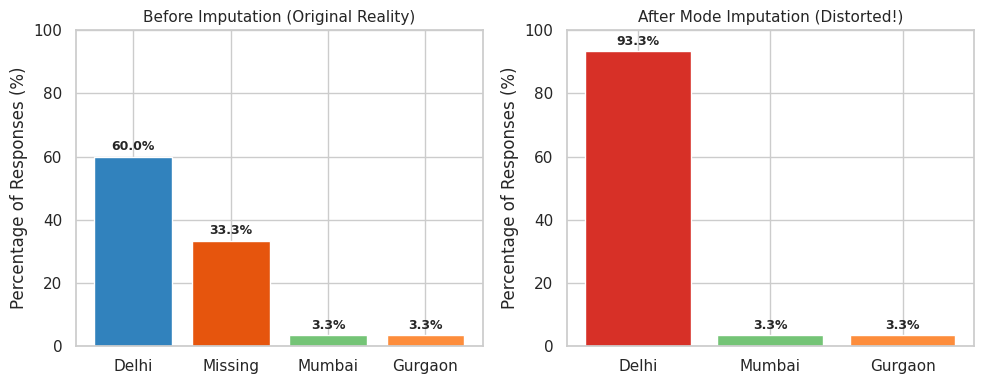

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4))

# Before Imputation
prop_before = survey['City'].fillna('Missing').value_counts(normalize=True) * 100
axes[0].bar(prop_before.index, prop_before.values, color=['#3182bd', '#e6550d', '#74c476', '#fd8d3c'])
axes[0].set_title('Before Imputation (Original Reality)', fontsize=11)
axes[0].set_ylabel('Percentage of Responses (%)')
axes[0].set_ylim(0, 100)
for i, v in enumerate(prop_before.values):
    axes[0].text(i, v + 2, f"{v:.1f}%", ha='center', fontweight='bold', fontsize=9)

# After Mode Imputation
prop_after = survey['City_Mode_Filled'].value_counts(normalize=True) * 100
axes[1].bar(prop_after.index, prop_after.values, color=['#d73027', '#74c476', '#fd8d3c'])
axes[1].set_title('After Mode Imputation (Distorted!)', fontsize=11)
axes[1].set_ylabel('Percentage of Responses (%)')
axes[1].set_ylim(0, 100)
for i, v in enumerate(prop_after.values):
    axes[1].text(i, v + 2, f"{v:.1f}%", ha='center', fontweight='bold', fontsize=9)

plt.tight_layout()
plt.show()


## 4. Real-World Case Study 1: Most Frequent Imputation on `Embarked`

### What are we doing?
In the Titanic dataset, `Embarked` has only **2 missing values out of 891 (0.22% missing)**.
Because missingness is tiny (<5%) and random, **Most Frequent (Mode) Imputation is ideal**.

#### Simple Implementation:
```python
embarked_mode = df['Embarked'].mode()[0]
df['Embarked_Imputed'] = df['Embarked'].fillna(embarked_mode)
```


In [5]:
# 1. Find the mode of Embarked
embarked_mode = df['Embarked'].mode()[0]
print(f"Embarked Mode (Most Frequent Port): '{embarked_mode}' (Southampton)")

# 2. Check proportions BEFORE imputation
prop_emb_before = df['Embarked'].value_counts(normalize=True) * 100
print("\n--- Embarked Proportions Before Imputation ---")
print(prop_emb_before.round(2))

# 3. Fill missing values with the mode
df['Embarked_Imputed'] = df['Embarked'].fillna(embarked_mode)

# 4. Check proportions AFTER imputation
prop_emb_after = df['Embarked_Imputed'].value_counts(normalize=True) * 100
print("\n--- Embarked Proportions After Imputation ---")
print(prop_emb_after.round(2))

# Verify zero nulls remain
print(f"\nRemaining nulls in Embarked_Imputed: {df['Embarked_Imputed'].isnull().sum()}")


Embarked Mode (Most Frequent Port): 'S' (Southampton)

--- Embarked Proportions Before Imputation ---
Embarked
S    72.44
C    18.90
Q     8.66
Name: proportion, dtype: float64

--- Embarked Proportions After Imputation ---
Embarked_Imputed
S    72.50
C    18.86
Q     8.64
Name: proportion, dtype: float64

Remaining nulls in Embarked_Imputed: 0


## 5. Real-World Case Study 2: Missing Category Imputation on `Cabin`

### What are we doing?
In the Titanic dataset, `Cabin` is missing in **687 out of 891 rows (77.10% missing)**.
If we filled 77% missing cabins with the most frequent cabin, we would distort the data entirely.

Instead, we extract the deck letter (`df['Cabin'].str[0]`) and fill missing values with an explicit new category: `'Missing'`.

#### Simple Implementation:
```python
df['Cabin_Deck'] = df['Cabin'].str[0].fillna('Missing')
```


In [6]:
# Extract deck letter (first character) and fill nulls with 'Missing'
df['Cabin_Deck'] = df['Cabin'].str[0].fillna('Missing')

print("--- Extracted Deck Frequencies ---")
print(df['Cabin_Deck'].value_counts())


--- Extracted Deck Frequencies ---
Cabin_Deck
Missing    687
C           59
B           47
D           33
E           32
A           15
F           13
G            4
T            1
Name: count, dtype: int64


### Proving That Missingness Contains Predictive Signal

### What are we doing?
We calculate the passenger survival rate for each deck level.

#### The Crucial Finding:
- Passengers with an assigned deck (`B`, `D`, `E`, `C`) had **60% to 75%** survival rates.
- Passengers with `Cabin = 'Missing'` had only a **29.99%** survival rate!

Why? Because 3rd-class passengers did not have private cabins. The fact that the cabin was missing was a direct indicator of ticket class and low survival odds.
Creating an explicit `'Missing'` category preserves this vital signal for our machine learning model!


--- Survival Rate by Deck ---
            Total_Passengers  Survival_Rate
Cabin_Deck                                 
D                         33           75.8
E                         32           75.0
B                         47           74.5
F                         13           61.5
C                         59           59.3
G                          4           50.0
A                         15           46.7
Missing                  687           30.0
T                          1            0.0


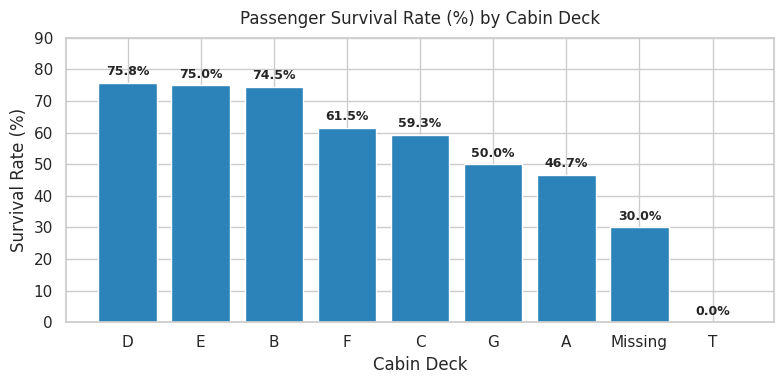

In [7]:
# Calculate survival rate by deck category
deck_survival = df.groupby('Cabin_Deck')['Survived'].agg(
    Total_Passengers='count',
    Survival_Rate=lambda s: round(s.mean() * 100, 1)
).sort_values(by='Survival_Rate', ascending=False)

print("--- Survival Rate by Deck ---")
print(deck_survival)

# Simple plot
plt.figure(figsize=(8, 4))
bars = plt.bar(deck_survival.index, deck_survival['Survival_Rate'], color='#2b83ba')
plt.title('Passenger Survival Rate (%) by Cabin Deck', fontsize=12, pad=10)
plt.xlabel('Cabin Deck')
plt.ylabel('Survival Rate (%)')
plt.ylim(0, 90)

for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2.0, yval + 1.5, f"{yval:.1f}%", ha='center', va='bottom', fontsize=9, fontweight='bold')

plt.tight_layout()
plt.show()


## 6. Production Machine Learning Workflow with `SimpleImputer`

### Meaningful Function Explanation: `SimpleImputer(strategy='most_frequent')` & `SimpleImputer(strategy='constant', fill_value='Missing')`

1. **What is this function?**  
   Scikit-Learn's standard transformer for imputing missing values in tabular datasets.
2. **Why did we use it?**  
   To prevent data leakage by learning categorical modes strictly from training data and applying them consistently to test and production data.
3. **What does it take as input?**  
   - `strategy='most_frequent'`: Automatically computes the mode of each column during `fit()`.
   - `strategy='constant', fill_value='Missing'`: Fills all missing entries with the custom text label `'Missing'`.
4. **What does it return?**  
   A fitted transformer object that transforms raw arrays or DataFrames with nulls into clean, complete arrays.
5. **How does it work internally?**  
   - During `fit(X_train)`: Scans the training data, computes the mode for each column, and stores it in the `statistics_` attribute.
   - During `transform(X)`: Replaces every `np.nan` with the corresponding value from `statistics_`.
6. **Why did we choose this approach?**  
   It packages seamlessly into Scikit-Learn `Pipeline` and `ColumnTransformer` objects for leakage-proof model deployment.
7. **What will happen if we don't use it?**  
   Manually calling `df['col'].mode()` before splitting causes test data leakage into training.
8. **Concrete Before / After Example:**  
   - Input `X_train`: `['Delhi', NaN, 'Delhi']` $\implies$ `fit()` stores `mode = 'Delhi'`.  
   - Input `X_test`: `[NaN, 'Mumbai']` $\implies$ `transform()` outputs `['Delhi', 'Mumbai']`.


In [8]:
# 1. Select features and target
features = ['Pclass', 'Sex', 'Age', 'Fare', 'Embarked', 'Cabin_Deck']
target = 'Survived'

X = df[features]
y = df[target]

# 2. Split FIRST to prevent data leakage
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"X_train rows: {len(X_train)}, X_test rows: {len(X_test)}")
print(f"Missing in X_train Embarked: {X_train['Embarked'].isnull().sum()}")
print(f"Missing in X_train Cabin_Deck: {X_train['Cabin_Deck'].isnull().sum()}")


X_train rows: 712, X_test rows: 179
Missing in X_train Embarked: 2
Missing in X_train Cabin_Deck: 0


### Building the Preprocessing Pipeline

### What are we doing?
We combine numerical and categorical preprocessing into one clean `ColumnTransformer`:
- Numerical (`Age`, `Fare`): Median imputation + standard scaling.
- Low-Missingness Categorical (`Embarked`, `Sex`, `Pclass`): Most Frequent (Mode) imputation + One-Hot Encoding.
- High-Missingness Categorical (`Cabin_Deck`): Missing Category (`'Missing'`) imputation + One-Hot Encoding.


In [9]:
# 1. Build ColumnTransformer with targeted imputation strategies
preprocessor = ColumnTransformer(
    transformers=[
        # Numerical: Median imputation + scaling
        ('num', Pipeline([
            ('imputer', SimpleImputer(strategy='median')),
            ('scaler', StandardScaler())
        ]), ['Age', 'Fare']),
        
        # Low-missingness categorical: Most frequent (mode) imputation + OneHot
        ('cat_mode', Pipeline([
            ('imputer', SimpleImputer(strategy='most_frequent')),
            ('encoder', OneHotEncoder(drop='first', sparse_output=False, handle_unknown='ignore'))
        ]), ['Embarked', 'Sex', 'Pclass']),
        
        # High-missingness categorical: Missing category ('Missing') + OneHot
        ('cat_missing', Pipeline([
            ('imputer', SimpleImputer(strategy='constant', fill_value='Missing')),
            ('encoder', OneHotEncoder(drop='first', sparse_output=False, handle_unknown='ignore'))
        ]), ['Cabin_Deck'])
    ]
)

# 2. Connect to Random Forest Classifier
model = Pipeline([
    ('preprocessor', preprocessor),
    ('classifier', RandomForestClassifier(n_estimators=100, max_depth=5, random_state=42))
])

# 3. Fit strictly on training data
model.fit(X_train, y_train)

# 4. Predict on unseen test data
y_pred = model.predict(X_test)
test_accuracy = accuracy_score(y_test, y_pred)

print("=" * 55)
print(f"Model Pipeline Test Accuracy: {test_accuracy * 100:.2f}%")
print("=" * 55)


Model Pipeline Test Accuracy: 77.09%


---

## What We Learned
- **Categorical Imputation Fundamentals**: Because categorical features contain labels, mathematical averages (mean/median) cannot be used. We must either fill with the mode or create a new category.
- **Most Frequent (Mode) Imputation**: Replaces nulls with the most commonly occurring category (`df['col'].mode()[0]`).
- **The Mode Inflation Trap**: When missingness is high, filling with the mode artificially inflates the majority class (e.g., Delhi jumping from 60% to 93%) and crushes minority diversity.
- **Missing Category Imputation**: Creates an explicit label (`'Missing'`), which makes no assumptions about the data and preserves informative missingness (e.g., missing Cabin indicating 3rd class).
- **Decision Rule**:
  - Use **Most Frequent Imputation** when missingness is low ($< 5\%$) and purely random.
  - Use **Missing Category Imputation** when missingness is moderate to high ($> 10\%$) or contains predictive signal.
- **Data Leakage Prevention**: When using `SimpleImputer(strategy='most_frequent')`, always fit strictly on `X_train` so that test set label frequencies never leak into training.

---

## Important Takeaways
1. **Always inspect missingness percentage before choosing a strategy**: Low missingness $\implies$ Mode fill; High missingness $\implies$ `'Missing'` category.
2. **Never overwrite meaningful missingness**: In real datasets, missing records often signal a specific user group (unemployed, unassigned cabin, no test needed).
3. **Imputed strings must still be encoded**: Imputing `'Missing'` leaves the column as text; you must still One-Hot Encode or Ordinal Encode it for machine learning models.
4. **Fit on `X_train`, transform on `X_test`**: Never calculate `.mode()` on the entire DataFrame before splitting.

---

## Common Mistakes
1. **Blindly filling high-missingness columns with the Mode**: Oversaturates the majority category and hides true population diversity.
2. **Forgetting `.dropna()` when computing `.mode()`**: In pure Python, ensure you don't treat `NaN` itself as a category when finding the mode.
3. **Assuming missingness is always random**: Overlooking that certain cohorts (like 3rd class passengers) systematically lack specific recorded data.
4. **Treating 5% as an unbreakable rule**: 5% is a practical rule of thumb; always evaluate domain context and sample size.

---

## Final Mental Model

```text
                     Missing Categorical Value
                                 │
                                 ▼
                     How much data is missing?
                                 │
                 ┌───────────────┴───────────────┐
                 ▼                               ▼
          Small (< 5%)                    Large (> 10%)
                 │                               │
                 ▼                               ▼
       Is missingness random?             Does missingness
                                           carry signal?
                 │                               │
         ┌───────┴───────┐                       ▼
         ▼               ▼             Create New Category:
     YES (MCAR)       NO (MNAR)            "Missing"
         │               │                       │
         ▼               ▼                       ▼
   Most Frequent      "Missing"         Preserves natural classes
    (Mode) Fill       Category           & informs the algorithm!
```
